In [27]:
import requests
import xmltodict
import pandas as pd
import time
import matplotlib.pyplot as plt
from scipy import stats
 
BASE  = "https://boardgamegeek.com/xmlapi2"
TOKEN = "7f5dd9f6-efef-41dd-8265-b88a15f97557"
HEADERS = {
    "User-Agent":    "DataScienceClass/1.0",
    "Authorization": f"Bearer {TOKEN}",
}

In [29]:
def bgg_get(endpoint: str, params: dict = {}, retries: int = 6) -> dict:
    url = f"{BASE}/{endpoint}"
    for attempt in range(retries):
        r = requests.get(url, params=params, headers=HEADERS)
        if r.status_code == 200:
            return xmltodict.parse(r.text)
        elif r.status_code == 202:
            wait = 3 * (attempt + 1)
            print(f"  BGG queuing (attempt {attempt+1}), retrying in {wait}s...")
            time.sleep(wait)
        elif r.status_code == 401:
            raise Exception(
                "HTTP 401 — token missing or wrong.\n"
                "Get one at: https://boardgamegeek.com/applications"
            )
        else:
            raise Exception(f"HTTP {r.status_code} at {url}")
    raise Exception("Max retries exceeded.")

def get_primary_name(name_field):
        names = name_field if isinstance(name_field, list) else [name_field]
        return next((n["@value"] for n in names if n.get("@type") == "primary"), "Unknown")
 
def get_links(links, link_type):
    if isinstance(links, dict):
        links = [links]
    return ", ".join(v["@value"] for v in links if v.get("@type") == link_type)

In [31]:
def fetch_game_details(ids: list) -> pd.DataFrame:
    """Fetch full metadata for a list of BGG game IDs (max ~20 per call)."""
    data  = bgg_get("thing", {"id": ",".join(str(i) for i in ids), "stats": 1})
    items = data.get("items", {}).get("item", [])
    if isinstance(items, dict):
        items = [items]
 
    records = []
    for item in items:
        s     = item.get("statistics", {}).get("ratings", {})
        links = item.get("link", [])
        if isinstance(links, dict):
            links = [links]
        
        records.append({
            "id":            int(item["@id"]),
            "name":          get_primary_name(item.get("name", [])),
            "year":          item.get("yearpublished",  {}).get("@value"),
            "min_players":   item.get("minplayers",     {}).get("@value"),
            "max_players":   item.get("maxplayers",     {}).get("@value"),
            "min_playtime":  item.get("minplaytime",    {}).get("@value"),
            "max_playtime":  item.get("maxplaytime",    {}).get("@value"),
            "min_age":       item.get("minage",         {}).get("@value"),
            "complexity":    s.get("averageweight",     {}).get("@value"),
            "avg_rating":    s.get("average",           {}).get("@value"),
            "bayes_rating":  s.get("bayesaverage",      {}).get("@value"),
            "num_ratings":   s.get("usersrated",        {}).get("@value"),
            "num_owned":     s.get("owned",             {}).get("@value"),
            "num_comments":  s.get("numcomments",       {}).get("@value"),
            "num_wanting":   s.get("wanting",           {}).get("@value"),
            "num_wishing":   s.get("wishing",           {}).get("@value"),
            "categories":    get_links(links, "boardgamecategory"),
            "mechanics":     get_links(links, "boardgamemechanic"),
            "designers":     get_links(links, "boardgamedesigner"),
            "publishers":    get_links(links, "boardgamepublisher"),
            "families":      get_links(links, "boardgamefamily"),
        })
    return pd.DataFrame(records)

In [33]:
# Run ID 1-100 for testing
all_details = []
for i in range(1, 101, 20):
    batch = list(range(i, i + 20))
    print(f"  Batch {i//20+1} ({len(batch)} games)...")
    all_details.append(fetch_game_details(batch))
    time.sleep(1)

games_df = pd.concat(all_details, ignore_index=True)
 
num_cols = ["year","min_players","max_players","min_playtime","max_playtime",
            "min_age","complexity","avg_rating","bayes_rating",
            "num_ratings","num_owned","num_comments","num_wanting",
            "num_wishing"]
games_df[num_cols] = games_df[num_cols].apply(pd.to_numeric, errors="coerce")

  Batch 1 (20 games)...
  Batch 2 (20 games)...
  Batch 3 (20 games)...
  Batch 4 (20 games)...
  Batch 5 (20 games)...


In [21]:
def fetch_hot_list() -> pd.DataFrame:
    data  = bgg_get("hot", {"type": "boardgame"})
    items = data.get("items", {}).get("item", [])
    return pd.DataFrame([{
        "hot_rank":  int(item["@rank"]),
        "id":        int(item["@id"]),
        "name":      item["name"]["@value"],
        "year":      item.get("yearpublished", {}).get("@value"),
    } for item in items])
 
hot_df = fetch_hot_list()
hot_df["year"] = pd.to_numeric(hot_df["year"], errors="coerce")

In [23]:
hot_df.head()

,hot_rank,id,name,year
0,1,470271,The Legacy Of Mars,2027
1,2,436217,The Lord of the Rings: Fate of the Fellowship,2025
2,3,391286,Terraria: The Board Game,2026
3,4,434654,Toy Battle,2025
4,5,415848,Lands of Evershade,2026



Correlation with avg_rating:
complexity      0.445
num_ratings     0.284
min_age         0.262
min_playtime    0.259
num_owned       0.237
max_playtime    0.082
max_players     0.034
min_players    -0.028


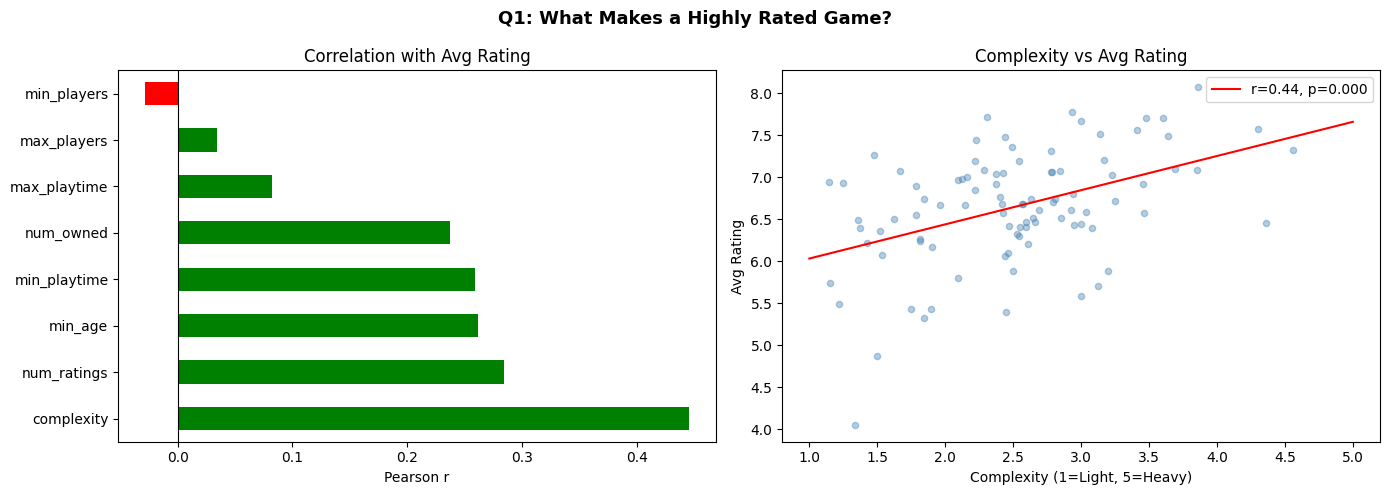

In [35]:
# Q1: What Makes a Highly Rated Game?
feature_cols = ["complexity","num_ratings","num_owned","min_players",
                "max_players","min_playtime","max_playtime","min_age"]
q1 = games_df[["avg_rating"] + feature_cols].dropna()
corr = q1.corr()["avg_rating"].drop("avg_rating").sort_values(ascending=False)
 
print("\nCorrelation with avg_rating:")
print(corr.round(3).to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q1: What Makes a Highly Rated Game?", fontsize=13, fontweight="bold")

corr.plot(kind="barh", ax=axes[0], color=["green" if v > 0 else "red" for v in corr])
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Correlation with Avg Rating")
axes[0].set_xlabel("Pearson r")
 
axes[1].scatter(q1["complexity"], q1["avg_rating"], alpha=0.4, s=20, color="steelblue")
m, b, r_val, p, _ = stats.linregress(q1["complexity"].dropna(),
                                      q1["avg_rating"].dropna())
x_line = pd.Series([1, 5])
axes[1].plot(x_line, m * x_line + b, color="red", linewidth=1.5,
             label=f"r={r_val:.2f}, p={p:.3f}")
axes[1].set_title("Complexity vs Avg Rating")
axes[1].set_xlabel("Complexity (1=Light, 5=Heavy)")
axes[1].set_ylabel("Avg Rating")
axes[1].legend()
 
plt.tight_layout()
plt.show()